# 10 Semantic Collusion Ring Detection

**Project:** Insurance Fraud Detection Assistant

**Notebook:** `10-semantic-collusion-ring-detection.ipynb`

In [87]:
# ==========================================
# Notebook 10
# Semantic Collusion Ring Detection
# ==========================================

import pandas as pd
import numpy as np

from sentence_transformers import SentenceTransformer

from sklearn.metrics.pairwise import cosine_similarity

import networkx as nx

In [88]:
claims_df = pd.read_csv("../data/insurance_claims.csv")

In [89]:
claims_df.head()

,claim_id,claimant_name,vehicle_vin,mechanic_shop,clinic_name,lawyer,claimant_statement,police_report,adjuster_notes,medical_bill,fraud_label
0,CLM001,Wendy Holland,FqH15433919443,Rapid Auto Repair,Care First Clinic,Smith & Associates,A vehicle rear-ended me while I was waiting at...,Witnesses confirmed another driver caused the ...,Section international though many movement.,5072,0
1,CLM002,Douglas Lara,acF49501195178,Rapid Auto Repair,Wellness Recovery Center,Anderson Legal,The vehicle changed lanes unexpectedly and hit...,Police observed damage consistent with reporte...,Budget Mrs part spend middle threat smile incr...,1541,0
2,CLM003,Chloe Murphy,xeQ24677572737,Rapid Auto Repair,Care First Clinic,Justice Partners,I was stopped at a red light when another vehi...,Accident report indicates claimant followed tr...,Similar never box line.,20226,1
3,CLM004,Jodi Reynolds MD,sPL40843321198,Rapid Auto Repair,Wellness Recovery Center,Justice Partners,The vehicle changed lanes unexpectedly and hit...,Police observed damage consistent with reporte...,Section season nor political bank.,7723,0
4,CLM005,Elizabeth Patel,mmr35740163797,Prime Vehicle Repair,Wellness Recovery Center,Smith & Associates,I was driving through an intersection when ano...,Witnesses confirmed another driver caused the ...,Kind compare across audience society.,23376,0


In [90]:
embedding_model = SentenceTransformer("sentence-transformers/all-mpnet-base-v2")

In [91]:
claim_embeddings = embedding_model.encode(
    claims_df["claimant_statement"].tolist(), show_progress_bar=True
)

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

In [92]:
similarity_matrix = cosine_similarity(claim_embeddings)

In [93]:
similarity_matrix.shape

(15, 15)

In [94]:
(15, 15)

(15, 15)

In [95]:
pair_results = []

for i in range(len(claims_df)):

    for j in range(i + 1, len(claims_df)):

        claim_1 = claims_df.iloc[i]
        claim_2 = claims_df.iloc[j]

        similarity = similarity_matrix[i][j]

        shared_mechanic = int(claim_1["mechanic_shop"] == claim_2["mechanic_shop"])

        shared_clinic = int(claim_1["clinic_name"] == claim_2["clinic_name"])

        shared_lawyer = int(claim_1["lawyer"] == claim_2["lawyer"])

        pair_results.append(
            {
                "claim_1": claim_1["claim_id"],
                "claim_2": claim_2["claim_id"],
                "similarity": similarity,
                "shared_mechanic": shared_mechanic,
                "shared_clinic": shared_clinic,
                "shared_lawyer": shared_lawyer,
            }
        )

pairs_df = pd.DataFrame(pair_results)

print("Pairs:", len(pairs_df))
pairs_df.head()

Pairs: 105


,claim_1,claim_2,similarity,shared_mechanic,shared_clinic,shared_lawyer
0,CLM001,CLM002,0.714800,1,0,0
1,CLM001,CLM003,0.761848,1,1,0
2,CLM001,CLM004,0.714800,1,0,0
3,CLM001,CLM005,0.748067,0,0,1
4,CLM001,CLM006,0.433312,0,0,1


In [96]:
# pair_results = []

In [97]:
# for i in range(len(claims_df)):

#     for j in range(i + 1, len(claims_df)):

#         claim_1 = claims_df.iloc[i]

#         claim_2 = claims_df.iloc[j]

In [98]:
# similarity = similarity_matrix[i][j]

In [99]:
# shared_mechanic = int(claim_1["mechanic_shop"] == claim_2["mechanic_shop"])

# shared_clinic = int(claim_1["clinic_name"] == claim_2["clinic_name"])

# shared_lawyer = int(claim_1["lawyer"] == claim_2["lawyer"])

In [100]:
pairs_df = pd.DataFrame(pair_results)

In [101]:
pairs_df.head()

,claim_1,claim_2,similarity,shared_mechanic,shared_clinic,shared_lawyer
0,CLM001,CLM002,0.714800,1,0,0
1,CLM001,CLM003,0.761848,1,1,0
2,CLM001,CLM004,0.714800,1,0,0
3,CLM001,CLM005,0.748067,0,0,1
4,CLM001,CLM006,0.433312,0,0,1


In [102]:
def calculate_ring_score(row):

    score = 0

    score += row["similarity"] * 50

    score += row["shared_mechanic"] * 20

    score += row["shared_clinic"] * 15

    score += row["shared_lawyer"] * 15

    return round(score, 2)

In [103]:
pairs_df["ring_score"] = pairs_df.apply(calculate_ring_score, axis=1)

In [104]:
pairs_df.head()

,claim_1,claim_2,similarity,shared_mechanic,shared_clinic,shared_lawyer,ring_score
0,CLM001,CLM002,0.714800,1,0,0,55.74
1,CLM001,CLM003,0.761848,1,1,0,73.09
2,CLM001,CLM004,0.714800,1,0,0,55.74
3,CLM001,CLM005,0.748067,0,0,1,52.40
4,CLM001,CLM006,0.433312,0,0,1,36.67


In [105]:
pairs_df.sort_values(by="ring_score", ascending=False).head(20)

,claim_1,claim_2,similarity,shared_mechanic,shared_clinic,shared_lawyer,ring_score
84,CLM009,CLM010,0.740162,1,1,1,87.01
15,CLM002,CLM004,1.000000,1,1,0,85.00
71,CLM007,CLM010,1.000000,1,0,1,85.00
78,CLM008,CLM010,0.692134,1,1,1,84.61
77,CLM008,CLM009,0.654495,1,1,1,82.72
1,CLM001,CLM003,0.761848,1,1,0,73.09
30,CLM003,CLM007,0.753231,1,1,0,72.66
5,CLM001,CLM007,0.748067,1,1,0,72.40
70,CLM007,CLM009,0.740162,1,0,1,72.01
27,CLM003,CLM004,0.698887,1,0,1,69.94


In [106]:
RING_THRESHOLD = 70

In [107]:
ring_candidates = pairs_df[pairs_df["ring_score"] >= RING_THRESHOLD]

In [108]:
ring_candidates

,claim_1,claim_2,similarity,shared_mechanic,shared_clinic,shared_lawyer,ring_score
1,CLM001,CLM003,0.761848,1,1,0,73.09
5,CLM001,CLM007,0.748067,1,1,0,72.40
15,CLM002,CLM004,1.000000,1,1,0,85.00
30,CLM003,CLM007,0.753231,1,1,0,72.66
70,CLM007,CLM009,0.740162,1,0,1,72.01
71,CLM007,CLM010,1.000000,1,0,1,85.00
77,CLM008,CLM009,0.654495,1,1,1,82.72
78,CLM008,CLM010,0.692134,1,1,1,84.61
84,CLM009,CLM010,0.740162,1,1,1,87.01


In [109]:
ring_graph = nx.Graph()

In [110]:
for _, row in ring_candidates.iterrows():

    ring_graph.add_edge(row["claim_1"], row["claim_2"], weight=row["ring_score"])

In [111]:
ring_graph.number_of_nodes()

8

In [112]:
ring_graph.number_of_edges()

9

In [113]:
import matplotlib.pyplot as plt

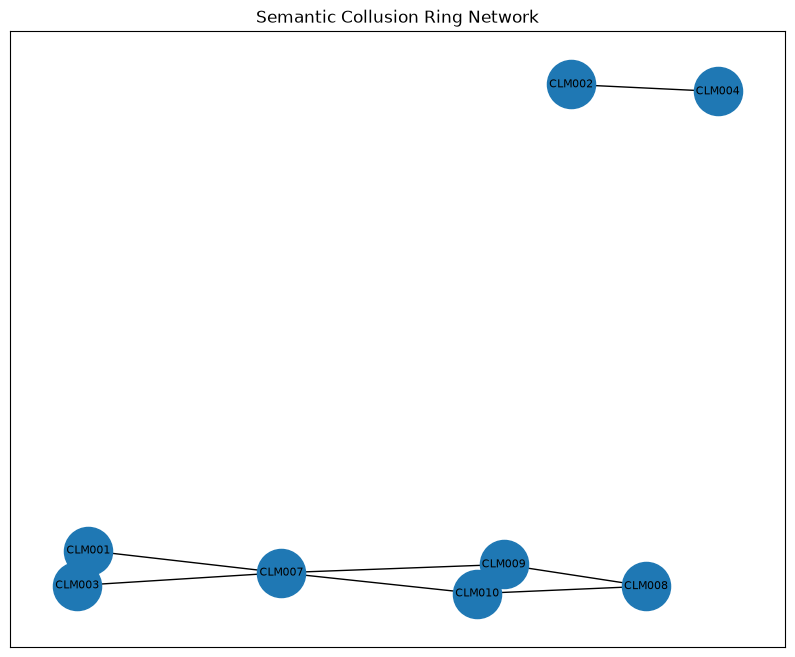

In [114]:
plt.figure(figsize=(10, 8))

pos = nx.spring_layout(ring_graph, seed=42)

nx.draw_networkx(ring_graph, pos, node_size=1200, font_size=8)

plt.title("Semantic Collusion Ring Network")

plt.show()

In [115]:
components = list(nx.connected_components(ring_graph))

In [116]:
len(components)

2

In [117]:
components

[{'CLM001', 'CLM003', 'CLM007', 'CLM008', 'CLM009', 'CLM010'},
 {'CLM002', 'CLM004'}]

In [118]:
ring_summary = []

In [119]:
for idx, component in enumerate(components):

    ring_summary.append(
        {"ring_id": idx + 1, "member_count": len(component), "members": list(component)}
    )

In [120]:
ring_summary_df = pd.DataFrame(ring_summary)

In [121]:
ring_summary_df

,ring_id,member_count,members
0,1,6,"[CLM010, CLM003, CLM009, CLM008, CLM007, CLM001]"
1,2,2,"[CLM002, CLM004]"


In [122]:
ring_summary_df["ring_risk_score"] = ring_summary_df["member_count"] * 10

In [123]:
ring_summary_df.sort_values(by="ring_risk_score", ascending=False)

,ring_id,member_count,members,ring_risk_score
0,1,6,"[CLM010, CLM003, CLM009, CLM008, CLM007, CLM001]",60
1,2,2,"[CLM002, CLM004]",20


In [124]:
largest_ring = max(components, key=len)

In [125]:
largest_ring

{'CLM001', 'CLM003', 'CLM007', 'CLM008', 'CLM009', 'CLM010'}

In [126]:
claims_df[claims_df["claim_id"].isin(largest_ring)][
    ["claim_id", "mechanic_shop", "clinic_name", "lawyer", "fraud_label"]
]

,claim_id,mechanic_shop,clinic_name,lawyer,fraud_label
0,CLM001,Rapid Auto Repair,Care First Clinic,Smith & Associates,0
2,CLM003,Rapid Auto Repair,Care First Clinic,Justice Partners,1
6,CLM007,Rapid Auto Repair,Care First Clinic,Premier Injury Law,0
7,CLM008,Rapid Auto Repair,Metro Injury Clinic,Premier Injury Law,1
8,CLM009,Rapid Auto Repair,Metro Injury Clinic,Premier Injury Law,1
9,CLM010,Rapid Auto Repair,Metro Injury Clinic,Premier Injury Law,1


In [127]:
ring_candidates.sort_values(by="ring_score", ascending=False).head(10)

,claim_1,claim_2,similarity,shared_mechanic,shared_clinic,shared_lawyer,ring_score
84,CLM009,CLM010,0.740162,1,1,1,87.01
15,CLM002,CLM004,1.000000,1,1,0,85.00
71,CLM007,CLM010,1.000000,1,0,1,85.00
78,CLM008,CLM010,0.692134,1,1,1,84.61
77,CLM008,CLM009,0.654495,1,1,1,82.72
1,CLM001,CLM003,0.761848,1,1,0,73.09
30,CLM003,CLM007,0.753231,1,1,0,72.66
5,CLM001,CLM007,0.748067,1,1,0,72.40
70,CLM007,CLM009,0.740162,1,0,1,72.01


In [128]:
investigation_queue = ring_candidates[
    ["claim_1", "claim_2", "similarity", "ring_score"]
]

In [129]:
investigation_queue.sort_values(by="ring_score", ascending=False)

,claim_1,claim_2,similarity,ring_score
84,CLM009,CLM010,0.740162,87.01
15,CLM002,CLM004,1.000000,85.00
71,CLM007,CLM010,1.000000,85.00
78,CLM008,CLM010,0.692134,84.61
77,CLM008,CLM009,0.654495,82.72
1,CLM001,CLM003,0.761848,73.09
30,CLM003,CLM007,0.753231,72.66
5,CLM001,CLM007,0.748067,72.40
70,CLM007,CLM009,0.740162,72.01


In [130]:
ring_candidates.to_csv("../data/semantic_ring_candidates.csv", index=False)

In [131]:
ring_summary_df.to_csv("../data/fraud_ring_summary.csv", index=False)

In [132]:
investigation_queue.to_csv("../data/semantic_ring_investigation_queue.csv", index=False)